# Section 1 — Customer Behavior Analysis & AI-driven Insights

In [1]:
import os
# Run from project root so data/, models/, reports/ resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: c:\Users\LENOVO\BLYS_Task


### 1.1 Load & Inspect Data

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

df = pd.read_csv("data/customer_data.csv")
print("Shape:", df.shape)
print()
print(df.dtypes)
df.head(10)

Shape: (20000, 6)

Customer_ID          int64
Booking_Frequency    int64
Avg_Spending         int64
Preferred_Service      str
Review_Text            str
Last_Activity          str
dtype: object


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Text,Last_Activity
0,1001,7,258,Body Scrub,Excellent!,3/26/2024
1,1002,4,367,Massage,Highly recommend,2/19/2024
2,1003,13,393,Massage,Too expensive,3/27/2024
3,1004,11,201,Massage,Not satisfied,4/17/2024
4,1005,8,436,Massage,Staff was friendly,3/23/2024
5,1006,13,414,Massage,Highly recommend,2/26/2024
6,1007,5,248,Massage,Not satisfied,4/17/2024
7,1008,7,138,Massage,Too expensive,2/25/2024
8,1009,10,297,Massage,Loved it!,3/26/2024
9,1010,3,372,Massage,Staff was friendly,3/21/2024


### 1.2 Data Preprocessing
#### 1.2a — Missing Value Handling

In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

# Numeric columns → fill with median
for col in ["Booking_Frequency", "Avg_Spending"]:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Filled {col} NaNs with median={median_val:.1f}")

# Categorical → fill with mode
for col in ["Preferred_Service", "Review_Text"]:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Filled {col} NaNs with mode=\"{mode_val}\"")

# Date → parse; fill with median date if any NaT
df["Last_Activity"] = pd.to_datetime(df["Last_Activity"])
if df["Last_Activity"].isnull().any():
    mid_ts = df["Last_Activity"].dropna().astype("int64").median()
    df["Last_Activity"].fillna(pd.Timestamp(mid_ts), inplace=True)

print("\nMissing after handling:", df.isnull().sum().sum())

=== Missing Values ===
Customer_ID          0
Booking_Frequency    0
Avg_Spending         0
Preferred_Service    0
Review_Text          0
Last_Activity        0
dtype: int64

Total missing cells: 0

Missing after handling: 0


#### 1.2b — Feature Engineering (Days Inactive)

In [4]:
reference_date = df["Last_Activity"].max()   # relative to latest date in dataset
df["Days_Inactive"] = (reference_date - df["Last_Activity"]).dt.days
print(df[["Customer_ID", "Last_Activity", "Days_Inactive"]].head(8))
print(f"\nDays_Inactive  min={df['Days_Inactive'].min()}  "
      f"max={df['Days_Inactive'].max()}  mean={df['Days_Inactive'].mean():.1f}")

   Customer_ID Last_Activity  Days_Inactive
0         1001    2024-03-26             34
1         1002    2024-02-19             70
2         1003    2024-03-27             33
3         1004    2024-04-17             12
4         1005    2024-03-23             37
5         1006    2024-02-26             63
6         1007    2024-04-17             12
7         1008    2024-02-25             64

Days_Inactive  min=0  max=119  mean=59.7


#### 1.2c — Sentiment Analysis on Review_Text (VADER)

Sentiment stats:
count    20000.000
mean         0.288
std          0.324
min         -0.325
25%          0.000
50%          0.420
75%          0.611
max          0.636
Name: Sentiment_Score, dtype: float64

Sentiment_Label
Positive    11935
Neutral      6049
Negative     2016
Name: count, dtype: int64


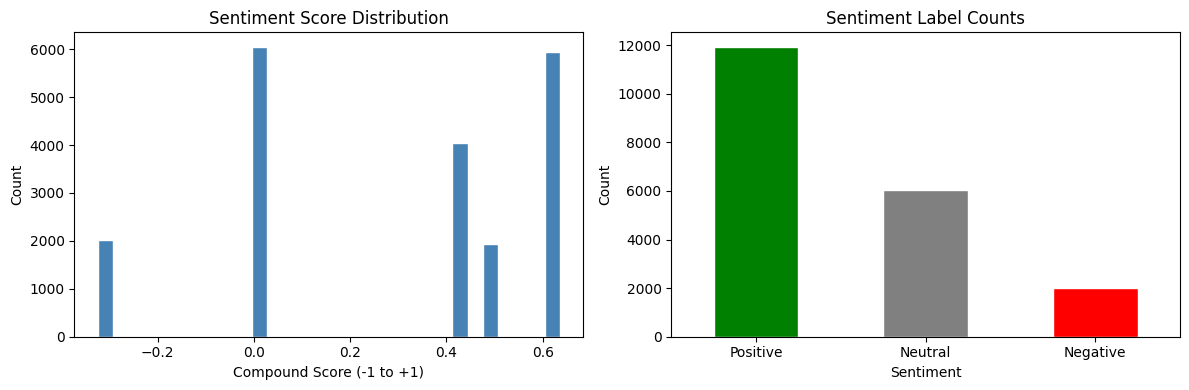

Saved: reports/sentiment_distribution.png


In [5]:
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# VADER is designed for short social text — much better than TextBlob here
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    return sia.polarity_scores(str(text))["compound"]  # -1 to +1

df["Sentiment_Score"] = df["Review_Text"].apply(get_sentiment)

def label_sentiment(s):
    if s >= 0.05:    return "Positive"
    elif s <= -0.05: return "Negative"
    else:            return "Neutral"

df["Sentiment_Label"] = df["Sentiment_Score"].apply(label_sentiment)

print("Sentiment stats:")
print(df["Sentiment_Score"].describe().round(3))
print()
print(df["Sentiment_Label"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Sentiment_Score"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Sentiment Score Distribution")
axes[0].set_xlabel("Compound Score (-1 to +1)")
axes[0].set_ylabel("Count")

df["Sentiment_Label"].value_counts().plot(
    kind="bar", ax=axes[1], color=["green","gray","red"], edgecolor="white")
axes[1].set_title("Sentiment Label Counts")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("reports/sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/sentiment_distribution.png")

#### 1.2d — Normalize Features (separate matrix for clustering)

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Keep original df intact for business-rule thresholds
# Cluster on a separate scaled copy
cluster_features = ["Booking_Frequency", "Avg_Spending", "Sentiment_Score", "Days_Inactive"]
X_raw = df[cluster_features].copy()

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=cluster_features,
    index=df.index
)

print("Scaled feature matrix (first 5 rows):")
print(X_scaled.head().round(4))

Scaled feature matrix (first 5 rows):
   Booking_Frequency  Avg_Spending  Sentiment_Score  Days_Inactive
0             0.4615        0.4633           0.9744         0.2857
1             0.2308        0.7060           0.7754         0.5882
2             0.9231        0.7639           0.3383         0.2773
3             0.7692        0.3363           0.0000         0.1008
4             0.5385        0.8597           0.8522         0.3109


### 1.3 Customer Segmentation — K-Means Clustering
#### 1.3a — Elbow Method

Auto-detected optimal k = 3  (largest inertia drop)
Silhouette at k=3: 0.226


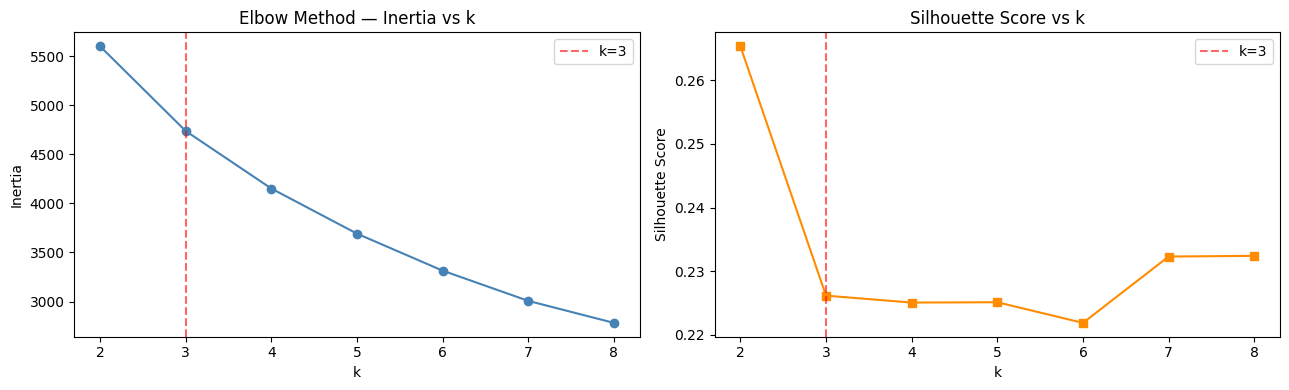

Saved: reports/elbow_silhouette.png


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

# Auto-detect elbow: largest drop in inertia
diffs = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
OPTIMAL_K = list(K_range)[diffs.index(max(diffs)) + 1]
print(f"Auto-detected optimal k = {OPTIMAL_K}  (largest inertia drop)")
print(f"Silhouette at k={OPTIMAL_K}: {silhouettes[OPTIMAL_K-2]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue")
axes[0].axvline(x=OPTIMAL_K, linestyle="--", color="red", alpha=0.6, label=f"k={OPTIMAL_K}")
axes[0].set_title("Elbow Method — Inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker="s", color="darkorange")
axes[1].axvline(x=OPTIMAL_K, linestyle="--", color="red", alpha=0.6, label=f"k={OPTIMAL_K}")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].legend()

plt.tight_layout()
plt.savefig("reports/elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/elbow_silhouette.png")

#### 1.3b — Fit Final K-Means

In [8]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(X_scaled)

seg_profile = df.groupby("Segment")[cluster_features].mean().round(2)
seg_profile["Customer_Count"] = df.groupby("Segment").size()
print("Segment Profiles (original scale):")
print(seg_profile.to_string())

# Auto-label each segment by its profile
def label_segment(row):
    if (row["Avg_Spending"]      > df["Avg_Spending"].quantile(0.66) and
        row["Booking_Frequency"] > df["Booking_Frequency"].quantile(0.66)):
        return "Champions"
    elif row["Days_Inactive"] > df["Days_Inactive"].quantile(0.66):
        return "At Risk"
    else:
        return "Casual Browsers"

seg_labels = seg_profile.apply(label_segment, axis=1)
df["Segment_Label"] = df["Segment"].map(seg_labels)
print("\nSegment label counts:")
print(df["Segment_Label"].value_counts())

Segment Profiles (original scale):
         Booking_Frequency  Avg_Spending  Sentiment_Score  Days_Inactive  Customer_Count
Segment                                                                                 
0                     3.99        273.13             0.54          60.15            6005
1                    10.99        274.47             0.54          60.06            5930
2                     7.54        276.18            -0.08          59.00            8065

Segment label counts:
Segment_Label
Casual Browsers    20000
Name: count, dtype: int64


#### 1.3c — Visualise Clusters

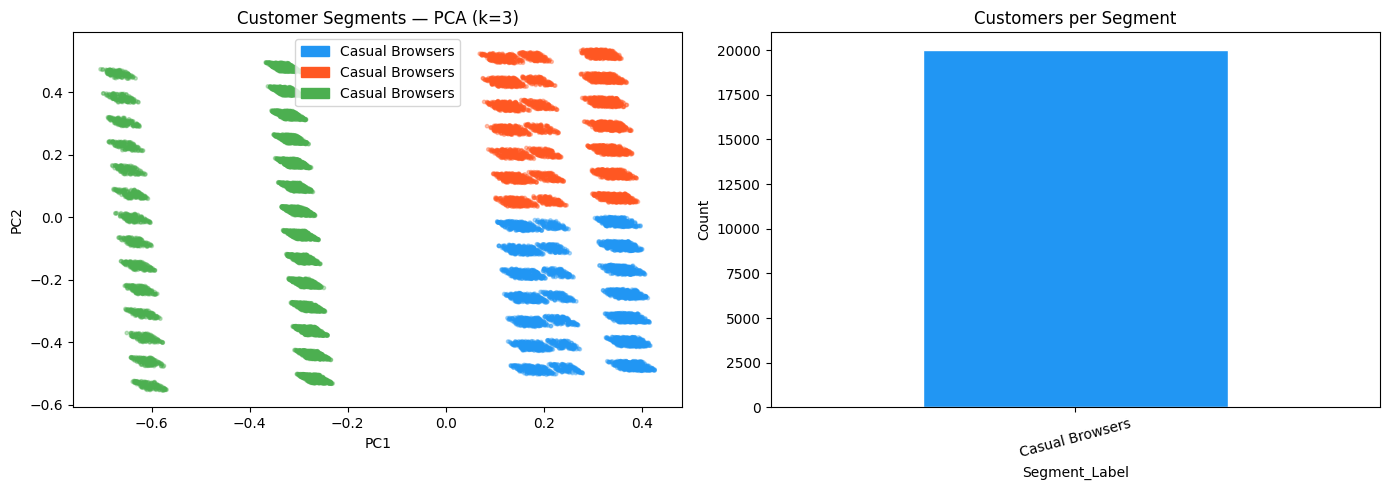

Saved: reports/customer_segments.png


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

palette = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]
colors   = [palette[s] for s in df["Segment"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.35, s=6)
axes[0].set_title(f"Customer Segments — PCA (k={OPTIMAL_K})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
patches = [mpatches.Patch(color=palette[i], label=seg_labels[i]) for i in range(OPTIMAL_K)]
axes[0].legend(handles=patches)

df["Segment_Label"].value_counts().plot(
    kind="bar", ax=axes[1], color=palette[:OPTIMAL_K], edgecolor="white")
axes[1].set_title("Customers per Segment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("reports/customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/customer_segments.png")

### 1.4 Insights — High-Value Customers & Churn Risk

High-value customers : 863  (4.3%)
Churn-risk customers : 2,401  (12.0%)

=== High-Value Profile ===
Booking_Frequency     12.47
Avg_Spending         441.97
Sentiment_Score        0.54
Days_Inactive         62.33
dtype: float64

=== Churn-Risk Profile ===
Booking_Frequency      3.84
Avg_Spending         272.19
Sentiment_Score        0.17
Days_Inactive         99.91
dtype: float64


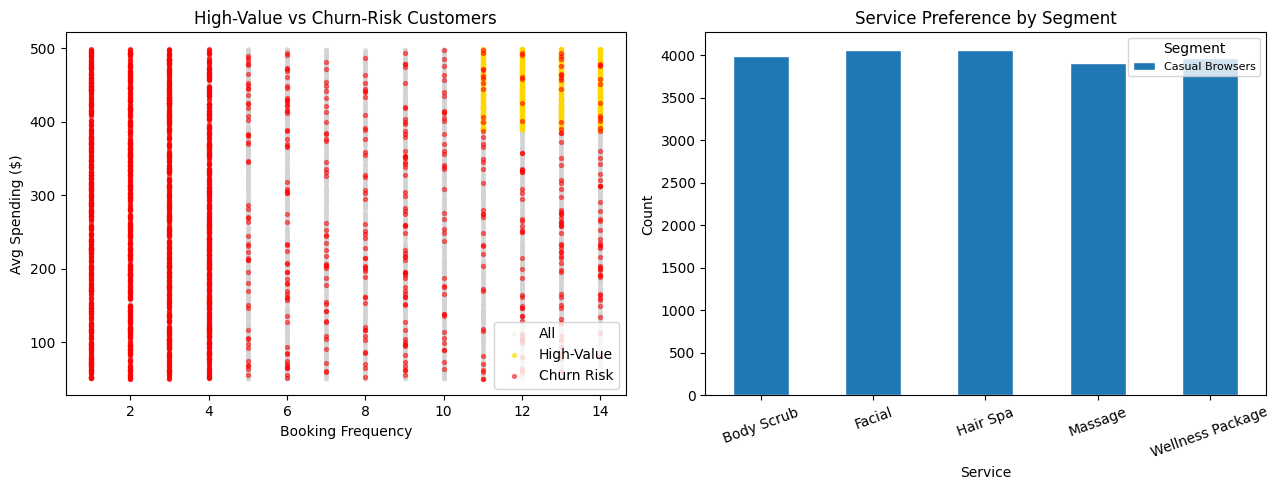

Saved: reports/insights.png


In [10]:
# ── High-Value: top-25% spending AND top-25% frequency AND positive sentiment
hv_mask = (
    (df["Avg_Spending"]      >= df["Avg_Spending"].quantile(0.75)) &
    (df["Booking_Frequency"] >= df["Booking_Frequency"].quantile(0.75)) &
    (df["Sentiment_Score"]   >  0.05)
)
high_value = df[hv_mask].copy()

# ── Churn Risk: top-33% inactivity AND (negative sentiment OR bottom-25% frequency)
churn_mask = (
    (df["Days_Inactive"]     >= df["Days_Inactive"].quantile(0.67)) &
    (
        (df["Sentiment_Score"]   <= -0.05) |
        (df["Booking_Frequency"] <= df["Booking_Frequency"].quantile(0.25))
    )
)
churn_risk = df[churn_mask].copy()

print(f"High-value customers : {len(high_value):,}  ({100*len(high_value)/len(df):.1f}%)")
print(f"Churn-risk customers : {len(churn_risk):,}  ({100*len(churn_risk)/len(df):.1f}%)")
print()
print("=== High-Value Profile ===")
print(high_value[cluster_features].mean().round(2))
print()
print("=== Churn-Risk Profile ===")
print(churn_risk[cluster_features].mean().round(2))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Booking_Frequency"], df["Avg_Spending"],
    alpha=0.15, s=5, color="lightgray", label="All")
axes[0].scatter(high_value["Booking_Frequency"], high_value["Avg_Spending"],
    alpha=0.6, s=8, color="gold", label="High-Value")
axes[0].scatter(churn_risk["Booking_Frequency"], churn_risk["Avg_Spending"],
    alpha=0.5, s=8, color="red", label="Churn Risk")
axes[0].set_xlabel("Booking Frequency")
axes[0].set_ylabel("Avg Spending ($)")
axes[0].set_title("High-Value vs Churn-Risk Customers")
axes[0].legend()

service_counts = (
    df.groupby(["Preferred_Service", "Segment_Label"])
    .size().unstack(fill_value=0)
)
service_counts.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("Service Preference by Segment")
axes[1].set_xlabel("Service")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Segment", fontsize=8)

plt.tight_layout()
plt.savefig("reports/insights.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/insights.png")

### 1.5 Generate Summary Report → reports/customer_analysis.md

In [11]:
seg_profile_display = df.groupby("Segment_Label")[cluster_features].mean().round(2)
seg_profile_display["Customer_Count"] = df.groupby("Segment_Label").size()
seg_profile_display.index.name = "Segment"

top_services_hv = high_value["Preferred_Service"].value_counts().head(3)
top_services_cr = churn_risk["Preferred_Service"].value_counts().head(3)

pos_count = (df["Sentiment_Label"] == "Positive").sum()
neu_count = (df["Sentiment_Label"] == "Neutral").sum()
neg_count = (df["Sentiment_Label"] == "Negative").sum()

report = (
    "# Customer Behavior Analysis Report\n"
    "*Blys AI Engineer Technical Assessment — Section 1*\n\n---\n\n"
    "## 1. Dataset Overview\n"
    "| Metric | Value |\n|--------|-------|\n"
    f"| Total customers | {len(df):,} |\n"
    f"| Date range | {df['Last_Activity'].min().date()} to {df['Last_Activity'].max().date()} |\n"
    f"| Features | Booking Frequency, Avg Spending, Sentiment Score, Days Inactive |\n\n---\n\n"
    "## 2. Data Preprocessing\n"
    f"- **Missing values**: {df.isnull().sum().sum()} remaining after handling\n"
    "- **Days Inactive**: derived from `Last_Activity` relative to most recent date\n"
    "- **Sentiment** (VADER compound score):\n"
    f"  - Positive: {pos_count:,} | Neutral: {neu_count:,} | Negative: {neg_count:,}\n"
    "- **Normalization**: MinMaxScaler on separate cluster matrix; originals preserved\n\n---\n\n"
    f"## 3. Customer Segmentation (K-Means, k={OPTIMAL_K})\n"
    + seg_profile_display.to_markdown() + "\n\n"
    "*Plots: `reports/customer_segments.png`, `reports/elbow_silhouette.png`*\n\n---\n\n"
    "## 4. Key Insights\n\n"
    "### 4.1 High-Value Customers\n"
    f"- **Count**: {len(high_value):,} ({100*len(high_value)/len(df):.1f}% of base)\n"
    f"- **Criteria**: Top-25% spending (>= ${high_value['Avg_Spending'].min():.0f})"    f" AND top-25% frequency AND positive sentiment\n"
    f"- **Avg spending**: ${high_value['Avg_Spending'].mean():.0f}"    f"  |  **Avg frequency**: {high_value['Booking_Frequency'].mean():.1f} bookings\n"
    f"- **Top services**: {', '.join(top_services_hv.index.tolist())}\n\n"
    "**Retention Strategies:**\n"
    "1. **Loyalty program** — tiered rewards (points per booking, free upgrade at milestones)\n"
    "2. **Early access** — priority booking for new therapists and premium packages\n"
    "3. **Personalised offers** — curated discounts on most-booked services\n"
    "4. **Dedicated account manager** — proactive outreach before typical booking cycle\n\n"
    "### 4.2 At-Risk Customers (Churn)\n"
    f"- **Count**: {len(churn_risk):,} ({100*len(churn_risk)/len(df):.1f}% of base)\n"
    f"- **Criteria**: Top-33% inactivity (>= {churn_risk['Days_Inactive'].min()} days)"    f" AND (negative sentiment OR bottom-25% frequency)\n"
    f"- **Avg days inactive**: {churn_risk['Days_Inactive'].mean():.0f}"    f"  |  **Avg sentiment**: {churn_risk['Sentiment_Score'].mean():.3f}\n"
    f"- **Top services**: {', '.join(top_services_cr.index.tolist())}\n\n"
    "**Re-engagement Tactics:**\n"
    "1. **Win-back discount** — 15-20% off next booking at 45 days inactivity\n"
    "2. **Push/SMS reminder** — personalised, references last service booked\n"
    "3. **Feedback survey** — understand dissatisfaction, offer resolution\n"
    "4. **New service intro** — highlight untried services to expand basket\n\n---\n\n"
    "## 5. Visualisations\n"
    "| File | Description |\n|------|-------------|\n"
    "| `reports/sentiment_distribution.png` | Sentiment score histogram |\n"
    "| `reports/elbow_silhouette.png` | Elbow + silhouette plots |\n"
    "| `reports/customer_segments.png` | PCA cluster scatter + segment sizes |\n"
    "| `reports/insights.png` | High-value vs churn-risk + service preference |\n"
)

with open("reports/customer_analysis.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Saved: reports/customer_analysis.md")
print()
print(report[:600])

Saved: reports/customer_analysis.md

# Customer Behavior Analysis Report
*Blys AI Engineer Technical Assessment — Section 1*

---

## 1. Dataset Overview
| Metric | Value |
|--------|-------|
| Total customers | 20,000 |
| Date range | 2024-01-01 to 2024-04-29 |
| Features | Booking Frequency, Avg Spending, Sentiment Score, Days Inactive |

---

## 2. Data Preprocessing
- **Missing values**: 0 remaining after handling
- **Days Inactive**: derived from `Last_Activity` relative to most recent date
- **Sentiment** (VADER compound score):
  - Positive: 11,935 | Neutral: 6,049 | Negative: 2,016
- **Normalization**: MinMaxScaler on sep
